# 07B – SHAP Local Explainability (Updated)

Uses the **cleaned dataset** and **production model**.

<Axes: >

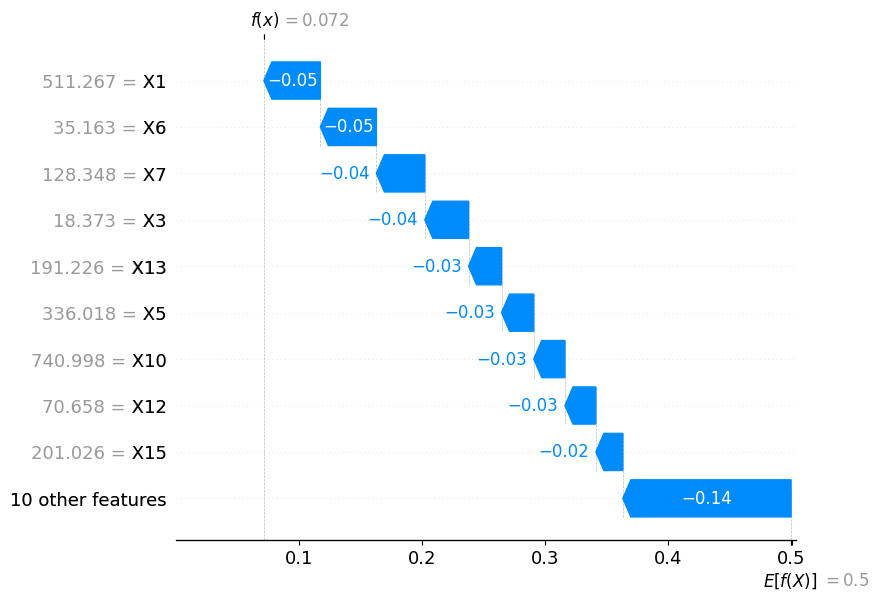

In [1]:
import pandas as pd
import joblib
import shap

DATA_PATH='../data/datasets/american_bankruptcy_cleaned.csv'
MODEL_PATH='../models/production_bankruptcy_model.joblib'

df=pd.read_csv(DATA_PATH)
target='status_label' if 'status_label' in df.columns else 'target'
X=df.drop(columns=[target])
if 'company_name' in X.columns:
    X=X.drop(columns=['company_name'])

model=joblib.load(MODEL_PATH)
instance=X.iloc[[0]]

explainer=shap.TreeExplainer(model)
# TreeExplainer on a binary classifier returns shape (n_samples, n_features, n_classes);
# select the positive ("failed") class for the waterfall plot.
values=explainer(instance)
sv = values[0, :, 1] if values.values.ndim == 3 else values[0]
shap.plots.waterfall(sv, show=False)


Generate local SHAP explanation for an individual company using the cleaned dataset.